In [1]:
# ================================================================
# CELL 1: Install the Python libraries used by the notebook for data handling, plots, machine learning, model saving, and SHAP explanations.
# ================================================================

!pip install -q pandas numpy matplotlib seaborn scikit-learn openpyxl joblib shap

In [2]:
# ================================================================
# CELL 2: Import the data, plotting, model-splitting, scaling, evaluation, and persistence tools used in later cells.
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# ================================================================
# CELL 3: Mount Google Drive so the notebook can read the experiment files and save exported model files.
# ================================================================

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ================================================================
# CELL 4: Set the existing Google Drive project folder as the dataset root and list its contents to confirm access.
# ================================================================

import os

base_path = "/content/drive/MyDrive/swhlqu-voltage_prediction_and_ISC_detection-dd56682"

print(os.listdir(base_path))

['ISC-detection-model', 'dataset-generation.py', 'voltage-and-power-forecasting', 'Supplementary files.pdf', 'README.md', 'NCM811_Random_test', 'NCM811_ISC_TEST', 'NCM811_full_life_cycle_dataset', 'NCM811_NORMAL_TEST', 'NCM523_dataset']


In [5]:
# ================================================================
# CELL 5: Build paths to the existing ISC and Normal experiment folders, then display their contents.
# ================================================================

import os

isc_path = os.path.join(base_path, "NCM811_ISC_TEST")
normal_path = os.path.join(base_path, "NCM811_NORMAL_TEST")

print("ISC folders:")
print(os.listdir(isc_path))

print("\nNormal folders:")
print(os.listdir(normal_path))

ISC folders:
['DST', 'CC']

Normal folders:
['DST', 'CC']


In [6]:
# ================================================================
# CELL 6: Count the CSV files in each ISC/Normal and CC/DST folder to summarize the source data inventory.
# ================================================================

for name, path in [
    ("ISC CC", os.path.join(isc_path, "CC")),
    ("ISC DST", os.path.join(isc_path, "DST")),
    ("Normal CC", os.path.join(normal_path, "CC")),
    ("Normal DST", os.path.join(normal_path, "DST"))
]:
    files = [
        f for f in os.listdir(path)
        if f.lower().endswith(".csv")
    ]

    print(f"{name}: {len(files)} CSV files")
    print("First 5:", files[:5])
    print()

ISC CC: 448 CSV files
First 5: ['ISC_CS_1.7CC_1.7CD_500ohm.csv', 'ISC_CS_1.5CC_1.0CD_600ohm.csv', 'ISC_CS_0.6CC_0.6CD_900ohm.csv', 'ISC_CS_1.5CC_2.0CD_500ohm.csv', 'ISC_CS_1.0CC_1.0CD_30ohm.csv']

ISC DST: 224 CSV files
First 5: ['ISC_CS_1.2CC_DST_200ohm.csv', 'ISC_CS_1.0CC_DST_200ohm.csv', 'ISC_CS_2.0CC_DST_800ohm.csv', 'ISC_CS_1.6CC_DST_300ohm.csv', 'ISC_CS_1.7CC_DST_30ohm.csv']

Normal CC: 448 CSV files
First 5: ['ISC_BD_1.5CC_1.0CD_20ohm.csv', 'ISC_BD_0.9CC_0.9CD_800ohm.csv', 'ISC_BD_1.0CC_1.0CD_1000ohm.csv', 'ISC_BD_2.0CC_1.5CD_700ohm.csv', 'ISC_BD_0.8CC_0.5CD_900ohm.csv']

Normal DST: 224 CSV files
First 5: ['ISC_BD_0.7CC_DST_10ohm.csv', 'ISC_BD_0.7CC_DST_700ohm.csv', 'ISC_BD_1.8CC_DST_1000ohm.csv', 'ISC_BD_1.6CC_DST_600ohm.csv', 'ISC_BD_1.4CC_DST_100ohm.csv']



In [7]:
# ================================================================
# CELL 7: Read experiment filenames and folder locations to create metadata, labels, and operating-condition columns for each CSV.
# ================================================================

import os
import re
import pandas as pd

# --------------------------------------------------
# Paths
# --------------------------------------------------

isc_cc_path = os.path.join(base_path, "NCM811_ISC_TEST", "CC")
isc_dst_path = os.path.join(base_path, "NCM811_ISC_TEST", "DST")

normal_cc_path = os.path.join(base_path, "NCM811_NORMAL_TEST", "CC")
normal_dst_path = os.path.join(base_path, "NCM811_NORMAL_TEST", "DST")


# --------------------------------------------------
# Collect file information
# --------------------------------------------------

records = []

folders = [
    ("ISC", "CC", isc_cc_path, 1),
    ("ISC", "DST", isc_dst_path, 1),
    ("Normal", "CC", normal_cc_path, 0),
    ("Normal", "DST", normal_dst_path, 0)
]

for fault_type, test_type, folder, label in folders:

    for filename in os.listdir(folder):

        if not filename.lower().endswith(".csv"):
            continue

        # Remove .csv
        name = filename.replace(".csv", "")

        # Extract resistance
        resistance_match = re.search(r"_(\d+)ohm$", name)

        if resistance_match:
            resistance = int(resistance_match.group(1))
        else:
            resistance = None

        # Extract the operating-condition part
        if "_DST_" in name:
            condition = "DST"
            cc_rate_match = re.search(r"_(\d+(?:\.\d+)?)CC_DST_", name)

            if cc_rate_match:
                cc_rate = float(cc_rate_match.group(1))
            else:
                cc_rate = None

            cd_rate = None

        else:
            condition = "CC_CD"

            cc_match = re.search(
                r"_(\d+(?:\.\d+)?)CC_",
                name
            )

            cd_match = re.search(
                r"CC_(\d+(?:\.\d+)?)CD_",
                name
            )

            cc_rate = float(cc_match.group(1)) if cc_match else None
            cd_rate = float(cd_match.group(1)) if cd_match else None

        records.append({
            "filename": filename,
            "fault_type": fault_type,
            "label": label,
            "test_type": test_type,
            "condition": condition,
            "CC_rate": cc_rate,
            "CD_rate": cd_rate,
            "resistance_ohm": resistance,
            "folder": folder
        })


# --------------------------------------------------
# Create metadata DataFrame
# --------------------------------------------------

metadata = pd.DataFrame(records)

print("Total experiments:", len(metadata))

print("\nFirst 10 records:")
display(metadata.head(10))

print("\nClass distribution:")
display(metadata["fault_type"].value_counts())

print("\nTest type:")
display(
    pd.crosstab(
        metadata["test_type"],
        metadata["fault_type"]
    )
)

print("\nResistance levels:")
print(
    sorted(metadata["resistance_ohm"].dropna().unique())
)

print("\nCC rates:")
print(
    sorted(metadata["CC_rate"].dropna().unique())
)

print("\nCD rates:")
print(
    sorted(metadata["CD_rate"].dropna().unique())
)

Total experiments: 1344

First 10 records:


,filename,fault_type,label,test_type,condition,CC_rate,CD_rate,resistance_ohm,folder
0,ISC_CS_1.7CC_1.7CD_500ohm.csv,ISC,1,CC,CC_CD,1.7,1.7,500,/content/drive/MyDrive/swhlqu-voltage_predicti...
1,ISC_CS_1.5CC_1.0CD_600ohm.csv,ISC,1,CC,CC_CD,1.5,1.0,600,/content/drive/MyDrive/swhlqu-voltage_predicti...
2,ISC_CS_0.6CC_0.6CD_900ohm.csv,ISC,1,CC,CC_CD,0.6,0.6,900,/content/drive/MyDrive/swhlqu-voltage_predicti...
3,ISC_CS_1.5CC_2.0CD_500ohm.csv,ISC,1,CC,CC_CD,1.5,2.0,500,/content/drive/MyDrive/swhlqu-voltage_predicti...
4,ISC_CS_1.0CC_1.0CD_30ohm.csv,ISC,1,CC,CC_CD,1.0,1.0,30,/content/drive/MyDrive/swhlqu-voltage_predicti...
5,ISC_CS_0.5CC_2.0CD_600ohm.csv,ISC,1,CC,CC_CD,0.5,2.0,600,/content/drive/MyDrive/swhlqu-voltage_predicti...
6,ISC_CS_0.8CC_1.0CD_600ohm.csv,ISC,1,CC,CC_CD,0.8,1.0,600,/content/drive/MyDrive/swhlqu-voltage_predicti...
7,ISC_CS_0.9CC_0.9CD_700ohm.csv,ISC,1,CC,CC_CD,0.9,0.9,700,/content/drive/MyDrive/swhlqu-voltage_predicti...
8,ISC_CS_0.7CC_0.7CD_500ohm.csv,ISC,1,CC,CC_CD,0.7,0.7,500,/content/drive/MyDrive/swhlqu-voltage_predicti...
9,ISC_CS_2.0CC_2.0CD_20ohm.csv,ISC,1,CC,CC_CD,2.0,2.0,20,/content/drive/MyDrive/swhlqu-voltage_predicti...



Class distribution:


,count
fault_type,
ISC,672
Normal,672



Test type:


fault_type,ISC,Normal
test_type,,
CC,448,448
DST,224,224



Resistance levels:
[np.int64(10), np.int64(20), np.int64(30), np.int64(50), np.int64(100), np.int64(200), np.int64(300), np.int64(400), np.int64(500), np.int64(600), np.int64(700), np.int64(800), np.int64(900), np.int64(1000)]

CC rates:
[np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0), np.float64(1.1), np.float64(1.2), np.float64(1.3), np.float64(1.4), np.float64(1.5), np.float64(1.6), np.float64(1.7), np.float64(1.8), np.float64(1.9), np.float64(2.0)]

CD rates:
[np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9), np.float64(1.0), np.float64(1.1), np.float64(1.2), np.float64(1.3), np.float64(1.4), np.float64(1.5), np.float64(1.6), np.float64(1.7), np.float64(1.8), np.float64(1.9), np.float64(2.0)]


# ================================================================
# RAW-DATA EXPLORATORY DATA ANALYSIS (EDA)
# ================================================================

These checks and visualizations run on the experiment metadata and representative raw battery CSV files, before `extract_features` is defined or used. File locations come from the existing `metadata` table (`folder` and `filename`), so no new dataset path is assumed.

All EDA and exploratory visualizations in this notebook use raw experiment metadata and source measurements before feature extraction.


RAW EXPERIMENT METADATA
Experiments: 1344
Unique source files: 1344

Metadata missing values:


,0
CD_rate,448



Experiment counts by fault type and test type:


test_type,CC,DST,All
fault_type,,,
ISC,448,224,672
Normal,448,224,672
All,896,448,1344



Experimental settings summary:


,count,mean,std,min,25%,50%,75%,max
CC_rate,1344.0,1.212500,0.485217,0.5,0.800,1.15,1.600,2.0
CD_rate,896.0,1.250000,0.512634,0.5,0.875,1.25,1.625,2.0
resistance_ohm,1344.0,400.714286,338.809745,10.0,50.000,350.00,700.000,1000.0


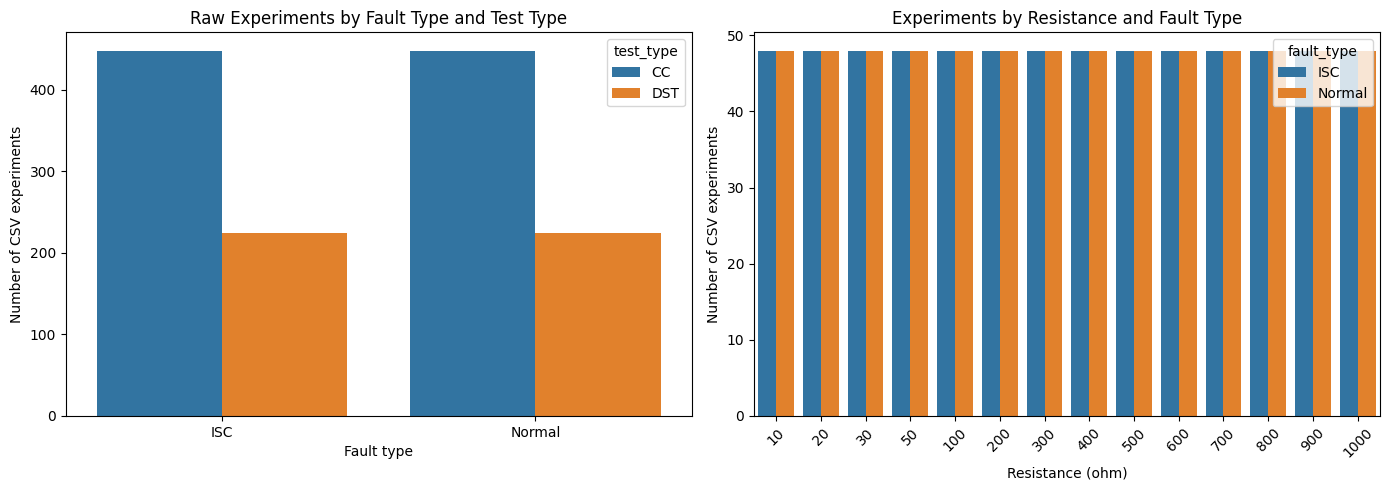

In [8]:
# ================================================================
# CELL 8: Summarize metadata completeness and experiment counts, then visualize class, test-type, and resistance distributions before feature extraction.
# ================================================================

# ================================================================
# RAW EDA 1: EXPERIMENT COUNTS AND METADATA QUALITY
# ================================================================
# `metadata` was created from the real CSV folders above. This cell
# summarizes the Normal/ISC and CC/DST experiment counts, checks missing
# metadata, and shows how experimental settings are represented.

raw_eda_metadata = metadata.copy()

print("=" * 72)
print("RAW EXPERIMENT METADATA")
print("=" * 72)
print("Experiments:", len(raw_eda_metadata))
print("Unique source files:", raw_eda_metadata["filename"].nunique())
print("\nMetadata missing values:")
raw_metadata_missing = raw_eda_metadata.isna().sum()
display(raw_metadata_missing[raw_metadata_missing > 0].sort_values(ascending=False))

print("\nExperiment counts by fault type and test type:")
display(pd.crosstab(raw_eda_metadata["fault_type"],
                    raw_eda_metadata["test_type"], margins=True))

print("\nExperimental settings summary:")
display(raw_eda_metadata[["CC_rate", "CD_rate", "resistance_ohm"]].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=raw_eda_metadata, x="fault_type", hue="test_type", ax=axes[0])
axes[0].set_title("Raw Experiments by Fault Type and Test Type")
axes[0].set_xlabel("Fault type")
axes[0].set_ylabel("Number of CSV experiments")
sns.countplot(data=raw_eda_metadata, x="resistance_ohm", hue="fault_type", ax=axes[1])
axes[1].set_title("Experiments by Resistance and Fault Type")
axes[1].set_xlabel("Resistance (ohm)")
axes[1].set_ylabel("Number of CSV experiments")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


Representative raw-file quality check:


,fault_type,test_type,filename,raw_rows,missing_required_columns,missing_values_in_required_columns
0,ISC,CC,ISC_CS_1.7CC_1.7CD_500ohm.csv,3273,None,0
1,ISC,DST,ISC_CS_1.2CC_DST_200ohm.csv,12835,None,28746
2,Normal,CC,ISC_BD_1.5CC_1.0CD_20ohm.csv,6015,None,0
3,Normal,DST,ISC_BD_0.7CC_DST_10ohm.csv,13354,None,24876


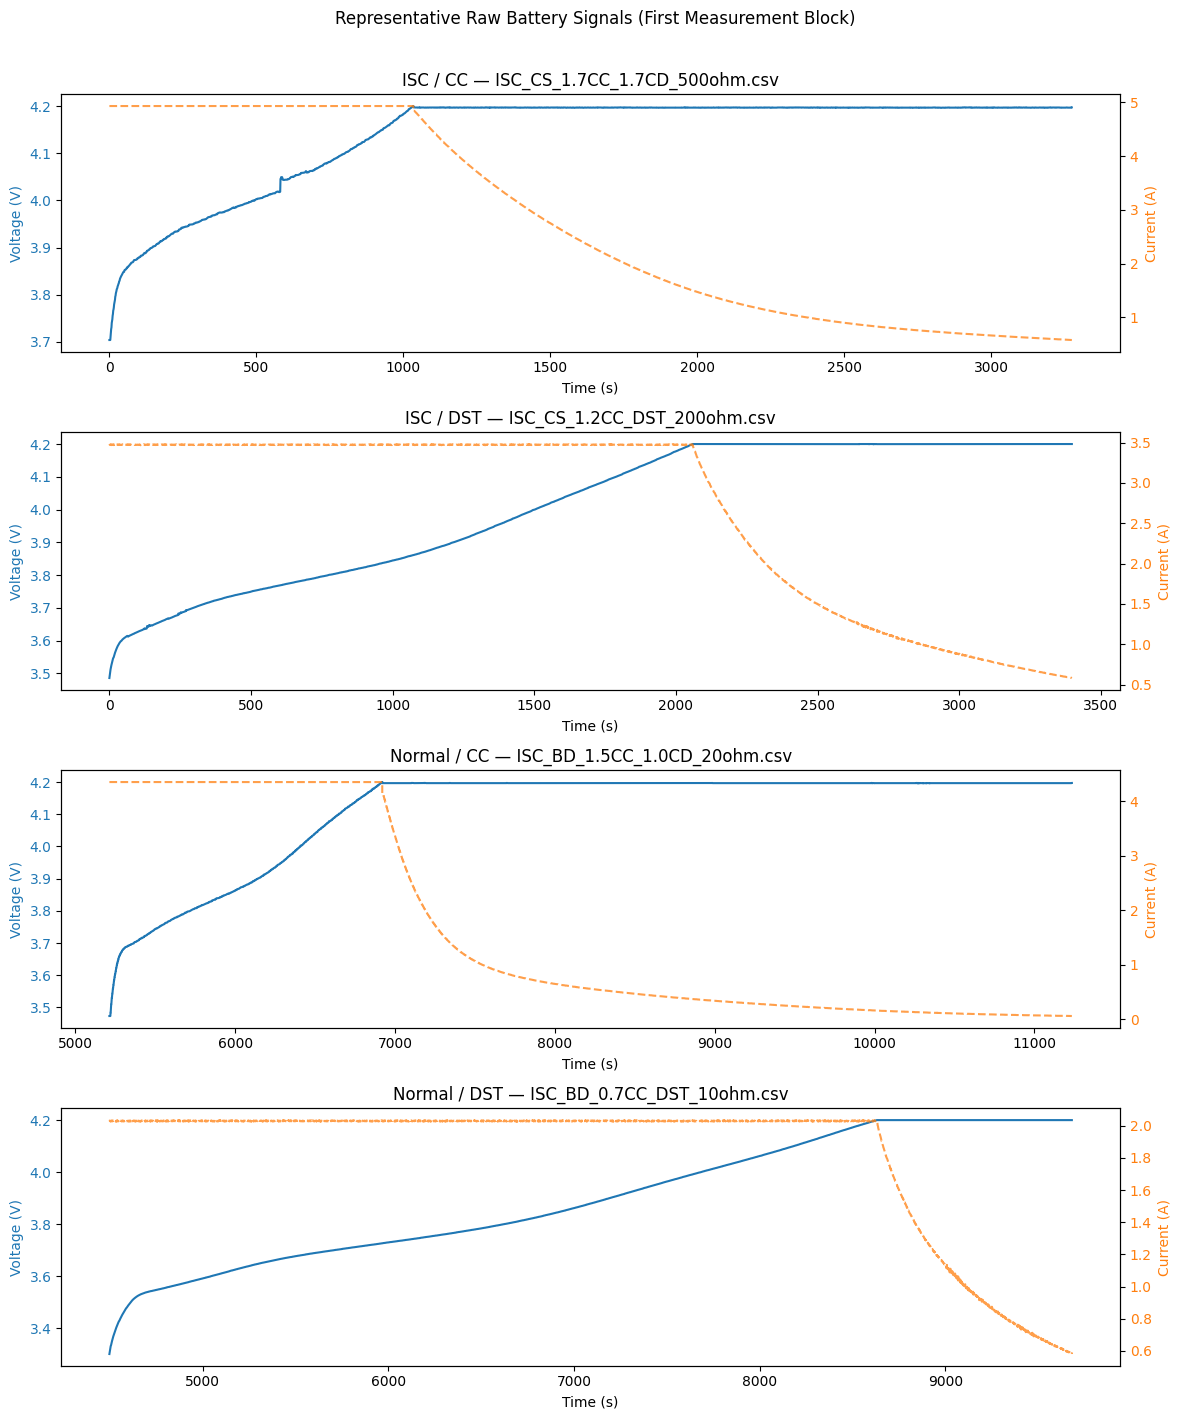

In [9]:
# ================================================================
# CELL 9: Select representative raw CSVs from the existing metadata, inspect required raw columns, and plot voltage/current over time before feature extraction.
# ================================================================

# ================================================================
# RAW EDA 2: REPRESENTATIVE BATTERY SIGNALS BEFORE FEATURE EXTRACTION
# ================================================================
# Pick one existing raw CSV for each available Normal/ISC and CC/DST
# combination. The selections are made from `metadata`; filenames and
# folders are not hard-coded. The plots show the first measurement block's
# voltage and current against its recorded time.

raw_time_col = "测试时间/Sec"
raw_voltage_col = "电压/V"
raw_current_col = "电流/A"
raw_signal_columns = [raw_time_col, raw_voltage_col, raw_current_col]
raw_signal_rows = (
    raw_eda_metadata.drop_duplicates(subset=["fault_type", "test_type"])
    .sort_values(["fault_type", "test_type"])
)

raw_signal_quality = []
raw_signal_data = []
for _, experiment in raw_signal_rows.iterrows():
    raw_file_path = os.path.join(experiment["folder"], experiment["filename"])
    raw_sample = pd.read_csv(raw_file_path)
    missing_columns = [col for col in raw_signal_columns if col not in raw_sample.columns]
    raw_signal_quality.append({
        "fault_type": experiment["fault_type"],
        "test_type": experiment["test_type"],
        "filename": experiment["filename"],
        "raw_rows": len(raw_sample),
        "missing_required_columns": ", ".join(missing_columns) if missing_columns else "None",
        "missing_values_in_required_columns": (
            int(raw_sample[raw_signal_columns].isna().sum().sum())
            if not missing_columns else np.nan
        ),
    })
    raw_signal_data.append((experiment, raw_sample))

print("Representative raw-file quality check:")
display(pd.DataFrame(raw_signal_quality))

if raw_signal_data:
    fig, axes = plt.subplots(len(raw_signal_data), 1,
                             figsize=(12, max(4, 3.5 * len(raw_signal_data))),
                             squeeze=False)
    for ax, (experiment, raw_sample) in zip(axes.ravel(), raw_signal_data):
        missing_columns = [col for col in raw_signal_columns if col not in raw_sample.columns]
        if missing_columns:
            ax.set_visible(False)
            print(f"Skipped raw signal plot for {experiment['filename']}; "
                  f"required columns missing: {missing_columns}")
            continue

        raw_time = pd.to_numeric(raw_sample[raw_time_col], errors="coerce")
        raw_voltage = pd.to_numeric(raw_sample[raw_voltage_col], errors="coerce")
        raw_current = pd.to_numeric(raw_sample[raw_current_col], errors="coerce")
        ax.plot(raw_time, raw_voltage, color="tab:blue", label="Voltage (V)")
        ax.set_ylabel("Voltage (V)", color="tab:blue")
        ax.tick_params(axis="y", labelcolor="tab:blue")
        ax.set_xlabel("Time (s)")
        ax.set_title(f"{experiment['fault_type']} / {experiment['test_type']} — "
                     f"{experiment['filename']}")
        current_ax = ax.twinx()
        current_ax.plot(raw_time, raw_current, color="tab:orange", alpha=0.75,
                        linestyle="--", label="Current (A)")
        current_ax.set_ylabel("Current (A)", color="tab:orange")
        current_ax.tick_params(axis="y", labelcolor="tab:orange")
    fig.suptitle("Representative Raw Battery Signals (First Measurement Block)", y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No representative raw files were available to plot.")


# ================================================================
# RAW SIGNAL DISTRIBUTIONS, CORRELATION, AND OUTLIER SCREENING
# ================================================================

This final pre-extraction EDA cell uses the representative raw CSVs already selected above. It examines the first measurement block's original time, current, capacity, SOC/DOD, and voltage columns. It does not call `extract_features` or create the model's engineered feature set.


Raw measurement rows included: 35477
Missing raw values by measurement column:


,0
测试时间/Sec,17874
电流/A,17874
容量/Ah,17874
SOC|DOD/%,17874
电压/V,17874


/tmp/ipykernel_4244/2263401956.py:55: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4244/2263401956.py:55: UserWarning: Glyph 27969 (\N{CJK UNIFIED IDEOGRAPH-6D41}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4244/2263401956.py:55: UserWarning: Glyph 23481 (\N{CJK UNIFIED IDEOGRAPH-5BB9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4244/2263401956.py:55: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4244/2263401956.py:55: UserWarning: Glyph 21387 (\N{CJK UNIFIED IDEOGRAPH-538B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages

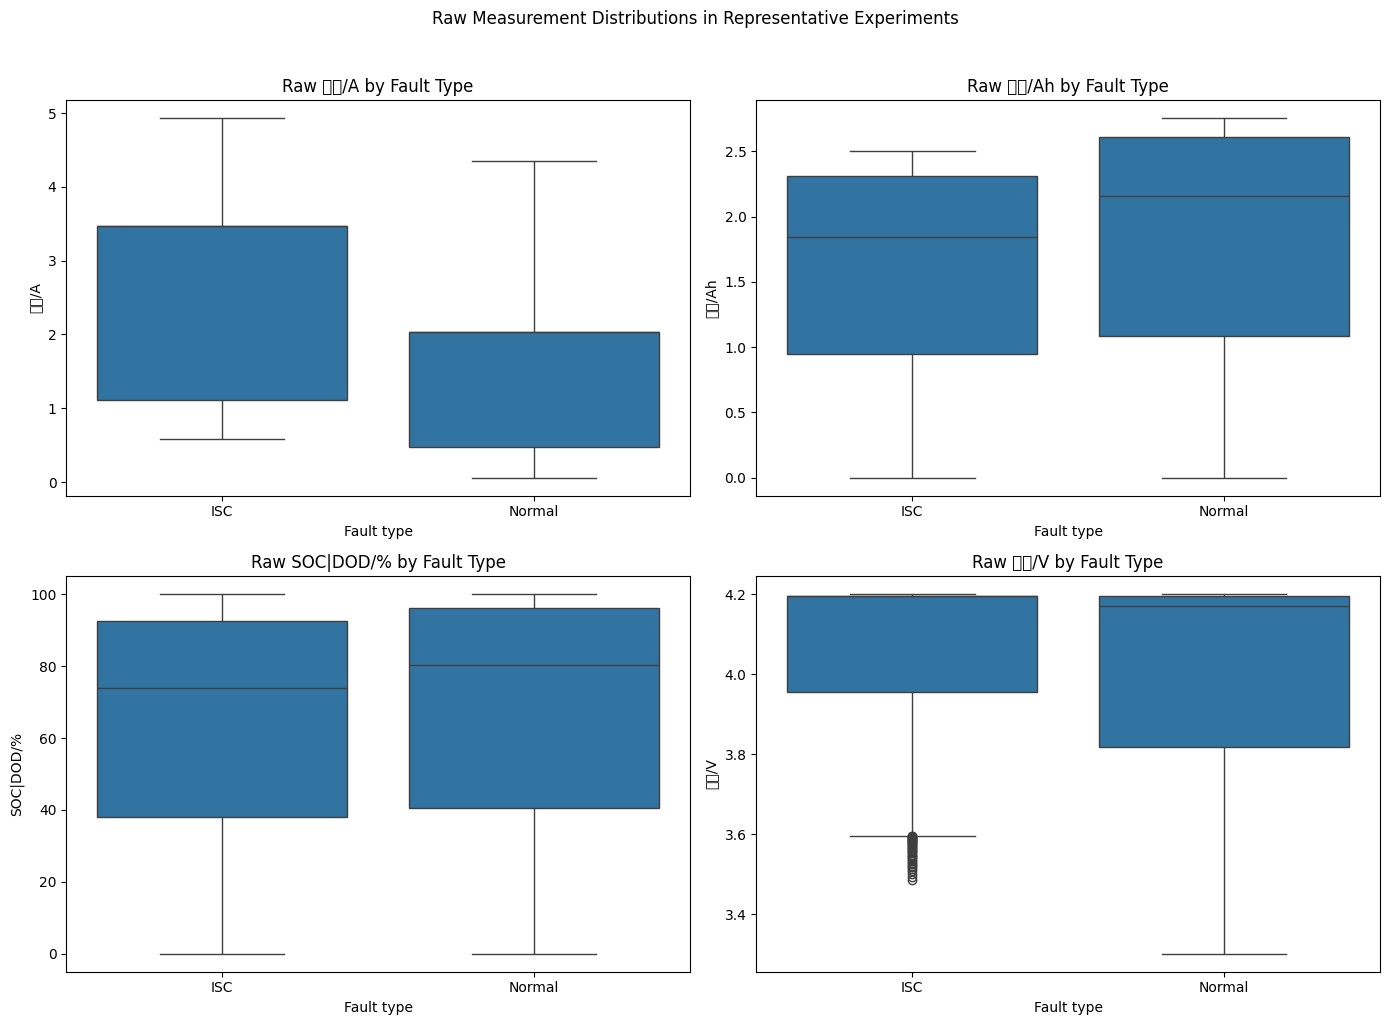

/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 30005 (\N{CJK UNIFIED IDEOGRAPH-7535}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 27969 (\N{CJK UNIFIED IDEOGRAPH-6D41}) missing from fon

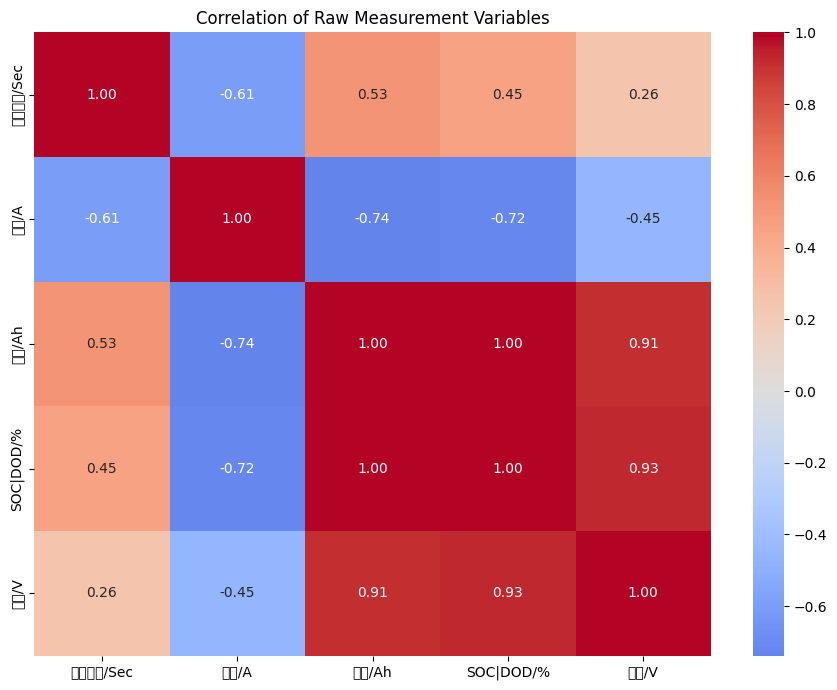

,raw_measurement,lower_IQR_bound,upper_IQR_bound,flagged_count,flagged_percent
0,测试时间/Sec,-6735.000000,17225.000000,0,0.00000
1,电流/A,-3.344877,7.563470,0,0.00000
2,容量/Ah,-1.138863,4.641811,0,0.00000
3,SOC|DOD/%,-43.555675,178.035725,0,0.00000
4,电压/V,3.374799,4.689903,23,0.13066


In [10]:
# ================================================================
# CELL 10: Compare original raw measurement distributions, correlations, and IQR outlier flags across the selected raw CSV samples; no rows are removed.
# ================================================================

# ================================================================
# RAW EDA 3: RAW MEASUREMENT DISTRIBUTIONS, CORRELATION, AND OUTLIERS
# ================================================================
# The data below comes directly from the representative source CSV files
# selected in RAW EDA 2. These are raw measurement rows, not model features.

raw_measurement_columns = [
    raw_time_col,
    raw_current_col,
    "容量/Ah",
    "SOC|DOD/%",
    raw_voltage_col,
]

raw_measurement_frames = []
for experiment, raw_sample in raw_signal_data:
    missing_columns = [column for column in raw_measurement_columns
                       if column not in raw_sample.columns]
    if missing_columns:
        print("Skipping raw distribution analysis for",
              experiment["filename"], "because columns are missing:", missing_columns)
        continue

    measurement_frame = raw_sample[raw_measurement_columns].copy()
    for column in raw_measurement_columns:
        measurement_frame[column] = pd.to_numeric(
            measurement_frame[column], errors="coerce"
        )
    measurement_frame["fault_type"] = experiment["fault_type"]
    measurement_frame["test_type"] = experiment["test_type"]
    raw_measurement_frames.append(measurement_frame)

if raw_measurement_frames:
    raw_measurements = pd.concat(raw_measurement_frames, ignore_index=True)
    raw_numeric_columns = [column for column in raw_measurement_columns
                           if column in raw_measurements.columns]

    print("Raw measurement rows included:", len(raw_measurements))
    print("Missing raw values by measurement column:")
    display(raw_measurements[raw_numeric_columns].isna().sum())

    # Compare raw electrical/operating measurements across the sampled
    # Normal and ISC experiments. Time is excluded from these boxplots.
    raw_distribution_columns = [raw_current_col, "容量/Ah", "SOC|DOD/%", raw_voltage_col]
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, column in zip(axes.ravel(), raw_distribution_columns):
        sns.boxplot(data=raw_measurements, x="fault_type", y=column, ax=ax)
        ax.set_title(f"Raw {column} by Fault Type")
        ax.set_xlabel("Fault type")
    plt.suptitle("Raw Measurement Distributions in Representative Experiments", y=1.02)
    plt.tight_layout()
    plt.show()

    # Correlation is calculated across raw measurement rows from the selected
    # representative files; it is not the engineered-feature correlation.
    raw_corr = raw_measurements[raw_numeric_columns].corr(numeric_only=True)
    plt.figure(figsize=(9, 7))
    sns.heatmap(raw_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Correlation of Raw Measurement Variables")
    plt.tight_layout()
    plt.show()

    # Flag raw values beyond the standard 1.5 x IQR fences. This is a review
    # aid only; no measurements or experiment rows are removed.
    raw_outlier_summary = []
    for column in raw_numeric_columns:
        values = raw_measurements[column].dropna()
        if values.empty:
            continue
        q1, q3 = values.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        flagged = int(((values < lower) | (values > upper)).sum())
        raw_outlier_summary.append({
            "raw_measurement": column,
            "lower_IQR_bound": lower,
            "upper_IQR_bound": upper,
            "flagged_count": flagged,
            "flagged_percent": 100 * flagged / len(values),
        })
    display(pd.DataFrame(raw_outlier_summary))
else:
    print("Raw distribution plots skipped: no representative CSV had all required columns.")


In [11]:
# ================================================================
# CELL 11: List the unique experimental configurations represented in metadata so the available test settings can be reviewed.
# ================================================================

print("Unique experimental configurations:")
display(
    metadata[
        [
            "fault_type",
            "test_type",
            "CC_rate",
            "CD_rate",
            "resistance_ohm"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["test_type", "CC_rate", "CD_rate", "resistance_ohm"]
    )
    .reset_index(drop=True)
)

Unique experimental configurations:


,fault_type,test_type,CC_rate,CD_rate,resistance_ohm
0,ISC,CC,0.5,0.5,10
1,Normal,CC,0.5,0.5,10
2,ISC,CC,0.5,0.5,20
3,Normal,CC,0.5,0.5,20
4,ISC,CC,0.5,0.5,30
...,...,...,...,...,...
1339,Normal,DST,2.0,NaN,800
1340,ISC,DST,2.0,NaN,900
1341,Normal,DST,2.0,NaN,900
1342,ISC,DST,2.0,NaN,1000


In [12]:
# ================================================================
# CELL 12: Define the existing feature-extraction function that reads one raw experiment CSV, cleans its measurement blocks, and calculates the model inputs.
# ================================================================

import numpy as np
import pandas as pd
import os


# =========================================================
# Extract features from one battery experiment
# =========================================================


def extract_features(file_path):

    df = pd.read_csv(file_path)

    # ==========================================
    # First measurement block
    # ==========================================

    block1 = df[
        [
            "测试时间/Sec",
            "电流/A",
            "容量/Ah",
            "SOC|DOD/%",
            "电压/V"
        ]
    ].copy()

    block1.columns = [
        "Time",
        "Current",
        "Capacity",
        "SOC_DOD",
        "Voltage"
    ]


    # ==========================================
    # Second measurement block
    # ==========================================

    block2 = df[
        [
            "测试时间/Sec.1",
            "电流/A.1",
            "容量/Ah.1",
            "SOC|DOD/%.1",
            "电压/V.1"
        ]
    ].copy()

    block2.columns = [
        "Time",
        "Current",
        "Capacity",
        "SOC_DOD",
        "Voltage"
    ]


    # Remove empty rows
    block1 = block1.dropna(subset=["Voltage"]).copy()
    block2 = block2.dropna(subset=["Voltage"]).copy()


    # Convert numeric columns
    numeric_columns = [
        "Current",
        "Capacity",
        "SOC_DOD",
        "Voltage"
    ]

    for column in numeric_columns:
        block1[column] = pd.to_numeric(
            block1[column],
            errors="coerce"
        )

        block2[column] = pd.to_numeric(
            block2[column],
            errors="coerce"
        )

    block1 = block1.dropna(subset=numeric_columns)
    block2 = block2.dropna(subset=numeric_columns)


    # ==========================================
    # Combine blocks ONLY for basic statistics
    # ==========================================

    data = pd.concat(
        [block1, block2],
        ignore_index=True
    )


    features = {}


    # ==========================================
    # Basic statistical features
    # ==========================================

    for column in numeric_columns:

        features[f"{column}_mean"] = data[column].mean()
        features[f"{column}_std"] = data[column].std()
        features[f"{column}_min"] = data[column].min()
        features[f"{column}_max"] = data[column].max()
        features[f"{column}_final"] = data[column].iloc[-1]


    # ==========================================
    # Derivatives — calculated separately
    # ==========================================

    voltage_changes = []

    current_changes = []

    for block in [block1, block2]:

        voltage_changes.extend(
            block["Voltage"].diff().dropna().tolist()
        )

        current_changes.extend(
            block["Current"].diff().dropna().tolist()
        )


    d_voltage = pd.Series(voltage_changes)
    d_current = pd.Series(current_changes)


    # ==========================================
    # Voltage derivative features
    # ==========================================

    features["dVoltage_mean"] = d_voltage.mean()
    features["dVoltage_std"] = d_voltage.std()
    features["dVoltage_min"] = d_voltage.min()
    features["dVoltage_max"] = d_voltage.max()


    # ==========================================
    # Current derivative features
    # ==========================================

    features["dCurrent_mean"] = d_current.mean()
    features["dCurrent_std"] = d_current.std()
    features["dCurrent_min"] = d_current.min()
    features["dCurrent_max"] = d_current.max()


    return features

In [13]:
# ================================================================
# CELL 13: Run the feature extractor on the notebook's existing example ISC file to inspect the extracted feature count and values.
# ================================================================

# Test with one ISC experiment

test_file = os.path.join(
    isc_cc_path,
    "ISC_CS_0.5CC_0.5CD_10ohm.csv"
)

test_features = extract_features(test_file)

print("Number of extracted features:",
      len(test_features))

print("\nExtracted features:")

for key, value in test_features.items():
    print(f"{key}: {value}")

Number of extracted features: 28

Extracted features:
Current_mean: 0.37386929758646426
Current_std: 1.3401195840728395
Current_min: -1.449591
Current_max: 1.449591
Current_final: -1.449405
Capacity_mean: 1.7566380172306546
Capacity_std: 1.1305008667009475
Capacity_min: 0.0
Capacity_max: 3.908007
Capacity_final: 2.238107
SOC_DOD_mean: 52.34163370241354
SOC_DOD_std: 29.88107857106045
SOC_DOD_min: 0.0
SOC_DOD_max: 100.0
SOC_DOD_final: 100.0
Voltage_mean: 3.792807837335158
Voltage_std: 0.2831217597234239
Voltage_min: 2.749876
Voltage_max: 4.200149
Voltage_final: 2.749876
dVoltage_mean: -2.858336443946745e-05
dVoltage_std: 0.00041984114495403386
dVoltage_min: -0.005271000000000026
dVoltage_max: 0.013330999999999982
dCurrent_mean: 3.5515117581187016e-05
dCurrent_std: 0.011370150855230321
dCurrent_min: -0.026971999999999996
dCurrent_max: 1.440662


In [14]:
# ================================================================
# CELL 14: Apply the feature extractor to every metadata record and assemble the experiment-level feature table with labels and configuration identifiers.
# ================================================================

def build_feature_dataset(metadata):

    all_features = []

    for index, row in metadata.iterrows():

        try:
            # ---------------------------------------
            # Extract features from the CSV
            # ---------------------------------------
            file_path = os.path.join(
                row["folder"],
                row["filename"]
            )

            features = extract_features(file_path)

            # ---------------------------------------
            # Create pair/configuration ID here
            # ---------------------------------------
            if row["test_type"] == "DST":

                pair_id = (
                    f"DST_"
                    f"CC{row['CC_rate']}_"
                    f"{row['resistance_ohm']}ohm"
                )

            else:

                pair_id = (
                    f"CC_"
                    f"CC{row['CC_rate']}_"
                    f"CD{row['CD_rate']}_"
                    f"{row['resistance_ohm']}ohm"
                )

            # ---------------------------------------
            # Add experiment information
            # ---------------------------------------
            features["filename"] = row["filename"]
            features["label"] = row["label"]
            features["fault_type"] = row["fault_type"]

            features["test_type"] = row["test_type"]
            features["CC_rate"] = row["CC_rate"]
            features["CD_rate"] = row["CD_rate"]
            features["resistance_ohm"] = row["resistance_ohm"]

            features["pair_id"] = pair_id

            all_features.append(features)

        except Exception as e:

            print(
                f"Error processing {row['filename']}: {e}"
            )

    return pd.DataFrame(all_features)

In [15]:
# ================================================================
# CELL 15: Inspect the completed feature table's dimensions, sample rows, label counts, and number of paired configurations.
# ================================================================

feature_df = build_feature_dataset(metadata)

print("Feature dataset shape:")
print(feature_df.shape)

print("\nFirst 5 rows:")
display(feature_df.head())

print("\nLabels:")
print(feature_df["label"].value_counts())

print("\nNumber of configurations:")
print(feature_df["pair_id"].nunique())

Feature dataset shape:
(1344, 36)

First 5 rows:


,Current_mean,Current_std,Current_min,Current_max,Current_final,Capacity_mean,Capacity_std,Capacity_min,Capacity_max,Capacity_final,...,dCurrent_min,dCurrent_max,filename,label,fault_type,test_type,CC_rate,CD_rate,resistance_ohm,pair_id
0,0.030684,3.933068,-4.930866,4.930866,-4.930866,1.528566,0.765881,0.0,2.490516,2.444852,...,-0.088976,0.001550,ISC_CS_1.7CC_1.7CD_500ohm.csv,1,ISC,CC,1.7,1.7,500,CC_CC1.7_CD1.7_500ohm
1,0.001500,3.222542,-2.898996,4.348958,-2.898685,1.485004,0.822767,0.0,2.668883,2.661208,...,-0.253287,0.000930,ISC_CS_1.5CC_1.0CD_600ohm.csv,1,ISC,CC,1.5,1.0,600,CC_CC1.5_CD1.0_600ohm
2,0.000188,1.688588,-1.739769,1.739956,-1.739397,1.375800,0.788714,0.0,2.654442,2.654040,...,-0.060825,0.001488,ISC_CS_0.6CC_0.6CD_900ohm.csv,1,ISC,CC,0.6,0.6,900,CC_CC0.6_CD0.6_900ohm
3,0.001256,4.391481,-5.803570,4.360120,-5.797990,1.542432,0.825158,0.0,2.631950,2.625320,...,-0.018600,0.020460,ISC_CS_1.5CC_2.0CD_500ohm.csv,1,ISC,CC,1.5,2.0,500,CC_CC1.5_CD2.0_500ohm
4,0.121760,2.603687,-2.900236,2.900236,-2.899926,1.516610,0.844406,0.0,2.787558,2.523580,...,-0.107267,0.000620,ISC_CS_1.0CC_1.0CD_30ohm.csv,1,ISC,CC,1.0,1.0,30,CC_CC1.0_CD1.0_30ohm



Labels:
label
1    672
0    672
Name: count, dtype: int64

Number of configurations:
672


In [16]:
# ================================================================
# CELL 16: Validate the engineered feature columns for missing or infinite values and duplicate filenames, then save the feature table to the existing Drive path.
# ================================================================

import numpy as np

# FEATURE EXTRACTION VALIDATION: MISSING/INFINITE VALUES AND SAVE OUTPUT
feature_columns = list(extract_features(test_file).keys())

print("Missing ML feature values:",
      feature_df[feature_columns].isnull().sum().sum())

print("Infinite ML feature values:",
      np.isinf(feature_df[feature_columns].to_numpy()).sum())

print("Duplicate experiment filenames:",
      feature_df["filename"].duplicated().sum())

# Save to Google Drive
save_path = "/content/drive/MyDrive/NCM811_experiment_features.csv"

feature_df.to_csv(save_path, index=False)

print("\nDataset saved successfully!")
print(save_path)

Missing ML feature values: 0
Infinite ML feature values: 0
Duplicate experiment filenames: 0

Dataset saved successfully!
/content/drive/MyDrive/NCM811_experiment_features.csv


In [17]:
# ================================================================
# CELL 17: Identify which engineered feature columns contain missing values so data-quality issues can be traced.
# ================================================================

# FEATURE EXTRACTION VALIDATION: IDENTIFY FEATURES WITH MISSING VALUES

# Find exactly which features contain missing values

missing_counts = feature_df[feature_columns].isnull().sum()

print("Features with missing values:")
print(missing_counts[missing_counts > 0].sort_values(ascending=False))

Features with missing values:
Series([], dtype: int64)


In [18]:
# ================================================================
# CELL 18: Show the experiments and metadata for rows that have one or more missing engineered feature values.
# ================================================================

# FEATURE EXTRACTION VALIDATION: IDENTIFY AFFECTED EXPERIMENTS

# Check which experiments contain the missing values

missing_rows = feature_df[
    feature_df[feature_columns].isnull().any(axis=1)
]

print("Number of affected experiments:", len(missing_rows))

display(
    missing_rows[
        ["filename", "fault_type", "test_type",
         "CC_rate", "CD_rate", "resistance_ohm"]
    ].head(20)
)

Number of affected experiments: 0


,filename,fault_type,test_type,CC_rate,CD_rate,resistance_ohm


In [19]:
# ================================================================
# CELL 19: Split by pair_id so records from one experimental configuration stay together, then create the train/test feature matrices and labels.
# ================================================================

from sklearn.model_selection import train_test_split

configs = feature_df["pair_id"].unique()

train_configs, test_configs = train_test_split(
    configs,
    test_size=0.20,
    random_state=42
)

train_df = feature_df[
    feature_df["pair_id"].isin(train_configs)
].copy()

test_df = feature_df[
    feature_df["pair_id"].isin(test_configs)
].copy()

X_train = train_df[feature_columns]
y_train = train_df["label"]

X_test = test_df[feature_columns]
y_test = test_df["label"]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining labels:")
print(y_train.value_counts())

print("\nTesting labels:")
print(y_test.value_counts())

print(
    "\nOverlapping configurations:",
    len(
        set(train_df["pair_id"]) &
        set(test_df["pair_id"])
    )
)

Training shape: (1074, 28)
Testing shape: (270, 28)

Training labels:
label
1    537
0    537
Name: count, dtype: int64

Testing labels:
label
1    135
0    135
Name: count, dtype: int64

Overlapping configurations: 0


LOGISTIC REGRESSION RESULTS
Accuracy : 0.8333
Precision: 0.8947
Recall   : 0.7556
F1 Score : 0.8193

Classification Report:
              precision    recall  f1-score   support

      Normal       0.79      0.91      0.85       135
         ISC       0.89      0.76      0.82       135

    accuracy                           0.83       270
   macro avg       0.84      0.83      0.83       270
weighted avg       0.84      0.83      0.83       270



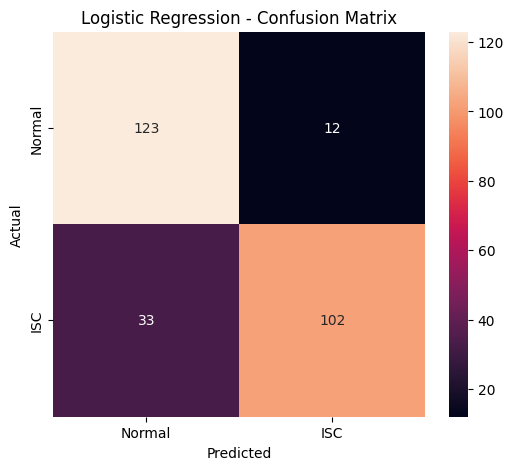

In [20]:
# ================================================================
# CELL 20: Train and evaluate the scaled Logistic Regression baseline, including its test metrics and confusion matrix.
# ================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns


# ==========================================
# Create Logistic Regression pipeline
# ==========================================

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])


# ==========================================
# Train
# ==========================================

lr_model.fit(X_train, y_train)


# ==========================================
# Prediction
# ==========================================

y_pred_lr = lr_model.predict(X_test)


# ==========================================
# Evaluation
# ==========================================

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)


print("LOGISTIC REGRESSION RESULTS")
print("=" * 40)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Normal", "ISC"]
    )
)


# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Normal", "ISC"],
    yticklabels=["Normal", "ISC"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

RANDOM FOREST RESULTS
Accuracy : 0.9778
Precision: 0.9850
Recall   : 0.9704
F1 Score : 0.9776

Classification Report:
              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98       135
         ISC       0.98      0.97      0.98       135

    accuracy                           0.98       270
   macro avg       0.98      0.98      0.98       270
weighted avg       0.98      0.98      0.98       270



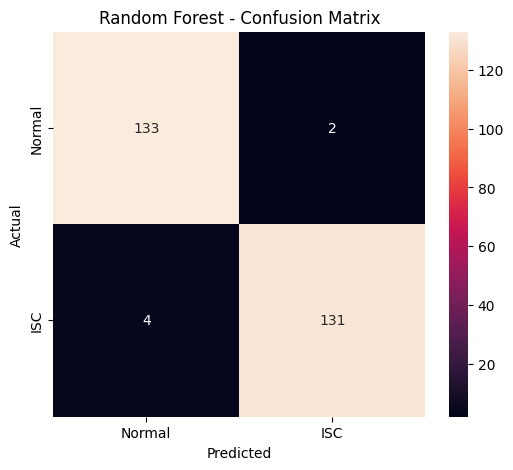

In [21]:
# ================================================================
# CELL 21: Train and evaluate the baseline Random Forest on the existing train/test split and display its classification results.
# ================================================================

from sklearn.ensemble import RandomForestClassifier

# ==========================================
# Random Forest
# ==========================================

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)


# ==========================================
# Evaluation
# ==========================================

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("RANDOM FOREST RESULTS")
print("=" * 40)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Normal", "ISC"]
    )
)


# ==========================================
# Confusion Matrix
# ==========================================

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Normal", "ISC"],
    yticklabels=["Normal", "ISC"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
# ================================================================
# CELL 22: Rank the baseline Random Forest's engineered features by importance and display the 15 highest-ranked features.
# ================================================================

importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print("TOP 15 FEATURES")
print("=" * 40)

display(importance.head(15))

TOP 15 FEATURES


,Feature,Importance
0,Current_mean,0.179696
8,Capacity_max,0.102022
20,dVoltage_mean,0.094946
23,dVoltage_max,0.059290
15,Voltage_mean,0.053720
6,Capacity_std,0.052669
11,SOC_DOD_std,0.045757
1,Current_std,0.035964
21,dVoltage_std,0.034314
22,dVoltage_min,0.032943


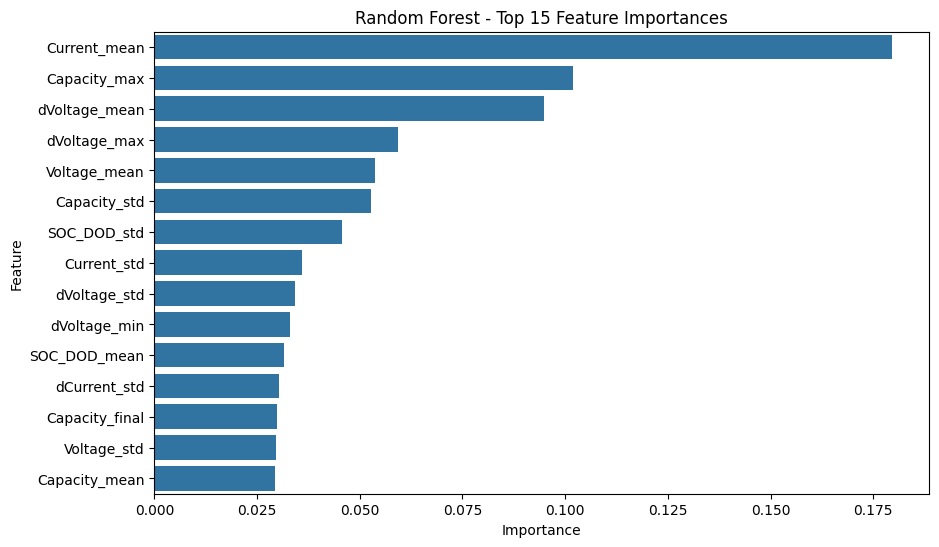

In [23]:
# ================================================================
# CELL 23: Plot the 15 most important baseline Random Forest features for a visual comparison.
# ================================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Random Forest - Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [24]:
# ================================================================
# CELL 24: Install XGBoost, which is used by the following baseline and grouped-tuning cells.
# ================================================================

!pip install -q xgboost

In [25]:
# ================================================================
# CELL 25: Train and evaluate the baseline XGBoost classifier on the existing train/test split.
# ================================================================

from xgboost import XGBClassifier

# ==========================================
# XGBoost
# ==========================================

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred_xgb = xgb_model.predict(X_test)


# ==========================================
# Evaluation
# ==========================================

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("XGBOOST RESULTS")
print("=" * 40)

print(f"Accuracy : {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall   : {recall_xgb:.4f}")
print(f"F1 Score : {f1_xgb:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_xgb,
        target_names=["Normal", "ISC"]
    )
)

XGBOOST RESULTS
Accuracy : 0.9630
Precision: 0.9699
Recall   : 0.9556
F1 Score : 0.9627

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.97      0.96       135
         ISC       0.97      0.96      0.96       135

    accuracy                           0.96       270
   macro avg       0.96      0.96      0.96       270
weighted avg       0.96      0.96      0.96       270



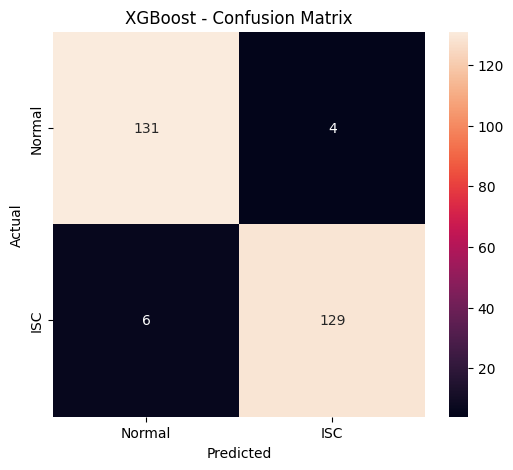

In [26]:
# ================================================================
# CELL 26: Plot the baseline XGBoost confusion matrix to show correct and incorrect test classifications.
# ================================================================

cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    xticklabels=["Normal", "ISC"],
    yticklabels=["Normal", "ISC"]
)

plt.title("XGBoost - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [27]:
# ================================================================
# CELL 27: Collect the baseline Logistic Regression, Random Forest, and XGBoost metrics into one comparison table.
# ================================================================

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        accuracy_rf,
        accuracy_xgb
    ],
    "Precision": [
        precision,
        precision_rf,
        precision_xgb
    ],
    "Recall": [
        recall,
        recall_rf,
        recall_xgb
    ],
    "F1 Score": [
        f1,
        f1_rf,
        f1_xgb
    ]
})

comparison = comparison.sort_values(
    "F1 Score",
    ascending=False
).reset_index(drop=True)

display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.977778,0.984962,0.970370,0.977612
1,XGBoost,0.962963,0.969925,0.955556,0.962687
2,Logistic Regression,0.833333,0.894737,0.755556,0.819277


In [28]:
# ================================================================
# CELL 28: Tune Random Forest hyperparameters with RandomizedSearchCV and GroupKFold, keeping experimental configurations separated across folds.
# ================================================================

from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.ensemble import RandomForestClassifier

# Groups = experimental configurations
groups = train_df["pair_id"]

group_cv = GroupKFold(n_splits=5)

rf_param_grid = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring="f1",
    cv=group_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(
    X_train,
    y_train,
    groups=groups
)

print("Best Random Forest parameters:")
print(rf_search.best_params_)

print("\nBest grouped CV F1-score:")
print(rf_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Random Forest parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 15}

Best grouped CV F1-score:
0.9358196798911775


In [29]:
# ================================================================
# CELL 29: Evaluate the best GroupKFold-tuned Random Forest on the held-out test set and report its classification metrics.
# ================================================================

best_rf = rf_search.best_estimator_

y_pred_rf_tuned = best_rf.predict(X_test)

print("GROUP-TUNED RANDOM FOREST")
print("=" * 45)

print(
    f"Accuracy : {accuracy_score(y_test, y_pred_rf_tuned):.4f}"
)

print(
    f"Precision: {precision_score(y_test, y_pred_rf_tuned):.4f}"
)

print(
    f"Recall   : {recall_score(y_test, y_pred_rf_tuned):.4f}"
)

print(
    f"F1 Score : {f1_score(y_test, y_pred_rf_tuned):.4f}"
)

GROUP-TUNED RANDOM FOREST
Accuracy : 0.9704
Precision: 0.9847
Recall   : 0.9556
F1 Score : 0.9699


In [30]:
# ================================================================
# CELL 30: Tune XGBoost hyperparameters using the same GroupKFold grouping strategy on the training data.
# ================================================================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ),
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring="f1",
    cv=group_cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(
    X_train,
    y_train,
    groups=groups
)

print("Best XGBoost parameters:")
print(xgb_search.best_params_)

print("\nBest grouped CV F1-score:")
print(xgb_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best XGBoost parameters:
{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.7}

Best grouped CV F1-score:
0.9370477798474866


In [31]:
# ================================================================
# CELL 31: Evaluate the best GroupKFold-tuned XGBoost on the held-out test set and report its classification metrics.
# ================================================================

best_xgb = xgb_search.best_estimator_

y_pred_xgb_tuned = best_xgb.predict(X_test)

print("GROUP-TUNED XGBOOST")
print("=" * 45)

print(
    f"Accuracy : {accuracy_score(y_test, y_pred_xgb_tuned):.4f}"
)

print(
    f"Precision: {precision_score(y_test, y_pred_xgb_tuned):.4f}"
)

print(
    f"Recall   : {recall_score(y_test, y_pred_xgb_tuned):.4f}"
)

print(
    f"F1 Score : {f1_score(y_test, y_pred_xgb_tuned):.4f}"
)

GROUP-TUNED XGBOOST
Accuracy : 0.9593
Precision: 0.9559
Recall   : 0.9630
F1 Score : 0.9594


In [32]:
# ================================================================
# CELL 32: Save the selected tuned Random Forest model as a pickle file for later reload and prediction checks.
# ================================================================

import joblib

# Save the final trained model
joblib.dump(best_rf, "final_isc_random_forest.pkl")

print("Final model saved successfully!")

Final model saved successfully!


In [33]:
# ================================================================
# CELL 33: Save the ordered feature-name list required to provide inputs to the saved model.
# ================================================================

joblib.dump(feature_columns, "isc_feature_columns.pkl")

print("Feature list saved successfully!")
print("Number of features:", len(feature_columns))

Feature list saved successfully!
Number of features: 28


In [34]:
# ================================================================
# CELL 34: Reload the saved Random Forest and feature list to confirm they can be read back from disk.
# ================================================================

# Reload model
loaded_model = joblib.load("final_isc_random_forest.pkl")

# Reload feature names
loaded_features = joblib.load("isc_feature_columns.pkl")

print("Model reloaded successfully!")
print("Features reloaded:", len(loaded_features))

Model reloaded successfully!
Features reloaded: 28


In [35]:
# ================================================================
# CELL 35: Compare predictions from the in-memory and reloaded Random Forest to confirm the saved model behaves identically.
# ================================================================

original_predictions = best_rf.predict(X_test)
loaded_predictions = loaded_model.predict(X_test)

print(
    "Predictions identical:",
    np.array_equal(original_predictions, loaded_predictions)
)

Predictions identical: True


In [36]:
# ================================================================
# CELL 36: Use one held-out test experiment to demonstrate the reloaded model's predicted class and class probabilities.
# ================================================================

# Take one unseen sample
sample = X_test.iloc[[0]]

# Actual label
actual = y_test.iloc[0]

# Prediction
prediction = loaded_model.predict(sample)[0]

# Probability
probability = loaded_model.predict_proba(sample)[0]

print("UNSEEN DATA PREDICTION")
print("=" * 40)

print("Actual label    :", actual)
print("Predicted label :", prediction)

if prediction == 0:
    print("Prediction      : NORMAL")
else:
    print("Prediction      : INTERNAL SHORT CIRCUIT (ISC)")

print("\nPrediction probabilities:")
print("Normal :", round(probability[0] * 100, 2), "%")
print("ISC    :", round(probability[1] * 100, 2), "%")

UNSEEN DATA PREDICTION
Actual label    : 1
Predicted label : 1
Prediction      : INTERNAL SHORT CIRCUIT (ISC)

Prediction probabilities:
Normal : 37.84 %
ISC    : 62.16 %


In [37]:
# ================================================================
# CELL 37: Display the installed SHAP version before computing model explanations.
# ================================================================

import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [38]:
# ================================================================
# CELL 38: Create a TreeExplainer for the selected Random Forest and calculate SHAP values for the held-out test examples.
# ================================================================

import shap

# Create SHAP explainer for the final Random Forest
explainer = shap.TreeExplainer(best_rf)

# Calculate SHAP values for the test data
shap_values = explainer.shap_values(X_test)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


In [39]:
# ================================================================
# CELL 39: Inspect the SHAP result type and dimensions so the next cells select the correct class output.
# ================================================================

print("Type:", type(shap_values))

if isinstance(shap_values, list):
    print("Number of outputs:", len(shap_values))
    for i, value in enumerate(shap_values):
        print(f"Output {i} shape:", value.shape)
else:
    print("SHAP values shape:", shap_values.shape)

Type: <class 'numpy.ndarray'>
SHAP values shape: (270, 28, 2)


In [40]:
# ================================================================
# CELL 40: Select the SHAP values associated with the ISC class for the following global and local explanations.
# ================================================================

# Select SHAP values for ISC class
shap_isc = shap_values[:, :, 1]

print("ISC SHAP shape:", shap_isc.shape)

ISC SHAP shape: (270, 28)


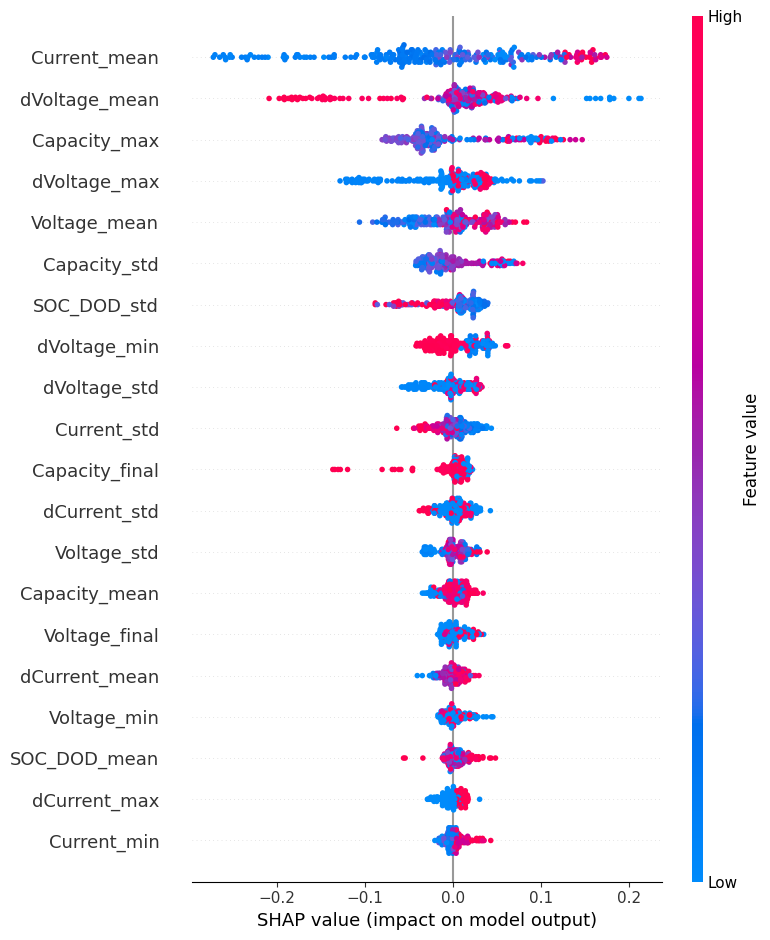

In [41]:
# ================================================================
# CELL 41: Plot the global SHAP summary to show which features influence ISC predictions across the test data.
# ================================================================

shap.summary_plot(
    shap_isc,
    X_test,
    feature_names=feature_columns
)

In [42]:
# ================================================================
# CELL 42: Choose a held-out test example and display its actual label and model prediction before explaining it locally.
# ================================================================

# Select the first unseen test sample
sample_index = 0

sample = X_test.iloc[[sample_index]]

print("Actual label:", y_test.iloc[sample_index])
print("Predicted label:", loaded_model.predict(sample)[0])

Actual label: 1
Predicted label: 1


In [43]:
# ================================================================
# CELL 43: Build and sort a table of feature values and SHAP contributions for the selected individual example.
# ================================================================

# SHAP values for the selected sample
sample_shap = shap_isc[sample_index]

# Create a dataframe for easier interpretation
local_explanation = pd.DataFrame({
    "Feature": feature_columns,
    "Feature_Value": sample.iloc[0].values,
    "SHAP_Value": sample_shap
})

# Sort by absolute SHAP impact
local_explanation["Absolute_SHAP"] = (
    local_explanation["SHAP_Value"].abs()
)

local_explanation = local_explanation.sort_values(
    "Absolute_SHAP",
    ascending=False
)

display(local_explanation.head(10))

,Feature,Feature_Value,SHAP_Value,Absolute_SHAP
8,Capacity_max,2.654442,-0.024568,0.024568
20,dVoltage_mean,-0.000040,0.023659,0.023659
1,Current_std,1.688588,0.023218,0.023218
11,SOC_DOD_std,29.714787,0.021859,0.021859
6,Capacity_std,0.788714,-0.021729,0.021729
21,dVoltage_std,0.000473,0.021718,0.021718
15,Voltage_mean,3.744272,-0.019405,0.019405
25,dCurrent_std,0.000764,0.018612,0.018612
4,Current_final,-1.739397,0.018596,0.018596
2,Current_min,-1.739769,0.018392,0.018392


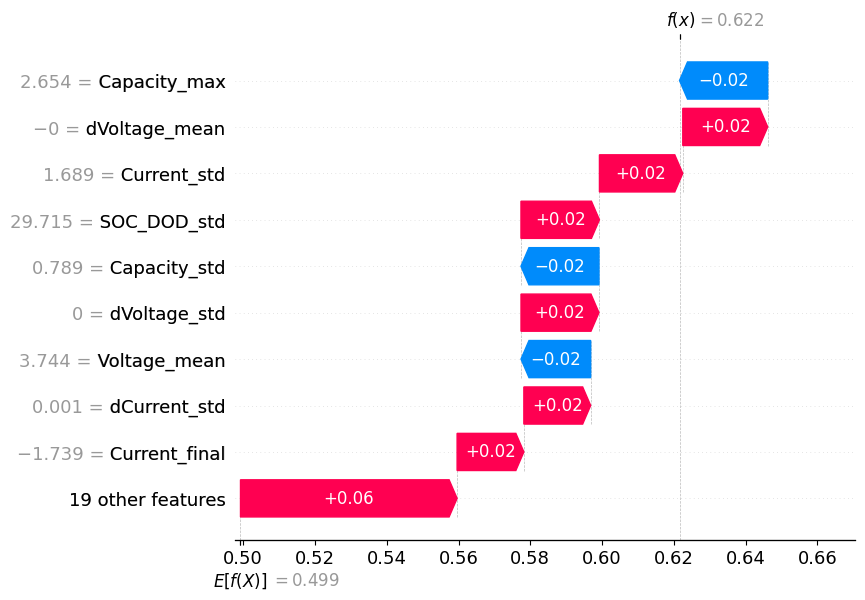

In [44]:
# ================================================================
# CELL 44: Plot a SHAP waterfall explanation showing how feature contributions move the selected example's prediction from the baseline.
# ================================================================

shap.waterfall_plot(
    shap.Explanation(
        values=sample_shap,
        base_values=explainer.expected_value[1],
        data=sample.iloc[0].values,
        feature_names=feature_columns
    )
)

In [45]:
# ================================================================
# CELL 45: Package the final model, ordered features, label mapping, and model details together, then save that package.
# ================================================================

import joblib
import pandas as pd
import numpy as np

# ==========================================
# FINAL MODEL PACKAGE
# ==========================================

final_model_package = {
    "model": best_rf,
    "features": feature_columns,
    "label_mapping": {
        0: "Normal",
        1: "Internal Short Circuit (ISC)"
    },
    "n_features": len(feature_columns),
    "model_name": "Group-Tuned Random Forest",
    "accuracy": accuracy_score(y_test, y_pred_rf_tuned),
    "precision": precision_score(y_test, y_pred_rf_tuned),
    "recall": recall_score(y_test, y_pred_rf_tuned),
    "f1_score": f1_score(y_test, y_pred_rf_tuned)
}

# Save everything together
joblib.dump(
    final_model_package,
    "NCM811_final_ISC_model.pkl"
)

print("Final model package saved successfully!")
print("Model:", final_model_package["model_name"])
print("Features:", final_model_package["n_features"])
print("Accuracy:", round(final_model_package["accuracy"], 4))
print("Precision:", round(final_model_package["precision"], 4))
print("Recall:", round(final_model_package["recall"], 4))
print("F1 Score:", round(final_model_package["f1_score"], 4))

Final model package saved successfully!
Model: Group-Tuned Random Forest
Features: 28
Accuracy: 0.9704
Precision: 0.9847
Recall: 0.9556
F1 Score: 0.9699


In [46]:
# ================================================================
# CELL 46: Reload the complete saved model package and display its model, feature, and label information.
# ================================================================

# Reload complete model package

package = joblib.load(
    "NCM811_final_ISC_model.pkl"
)

loaded_final_model = package["model"]
loaded_feature_columns = package["features"]
loaded_label_mapping = package["label_mapping"]

print("FINAL MODEL PACKAGE RELOADED")
print("=" * 40)

print("Model:", package["model_name"])
print("Number of features:", package["n_features"])
print("Labels:", loaded_label_mapping)

FINAL MODEL PACKAGE RELOADED
Model: Group-Tuned Random Forest
Number of features: 28
Labels: {0: 'Normal', 1: 'Internal Short Circuit (ISC)'}


In [47]:
# ================================================================
# CELL 47: Evaluate the reloaded model package on the held-out test set and compare its predictions with the tuned model.
# ================================================================

# Predict using the reloaded model

final_predictions = loaded_final_model.predict(X_test)

final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

print("Reloaded model accuracy:",
      round(final_accuracy, 4))

print(
    "Predictions identical:",
    np.array_equal(
        y_pred_rf_tuned,
        final_predictions
    )
)

Reloaded model accuracy: 0.9704
Predictions identical: True


In [50]:
# ================================================================
# CELL 48: Combine baseline and group-tuned model metrics into a final comparison table sorted by F1 score.
# ================================================================

# Compare baseline and GroupKFold-tuned model performance
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Group-Tuned Random Forest",
        "Group-Tuned XGBoost"
    ],
    "Accuracy": [
        accuracy,
        accuracy_rf,
        accuracy_xgb,
        accuracy_score(y_test, y_pred_rf_tuned),
        accuracy_score(y_test, y_pred_xgb_tuned)
    ],
    "Precision": [
        precision,
        precision_rf,
        precision_xgb,
        precision_score(y_test, y_pred_rf_tuned),
        precision_score(y_test, y_pred_xgb_tuned)
    ],
    "Recall": [
        recall,
        recall_rf,
        recall_xgb,
        recall_score(y_test, y_pred_rf_tuned),
        recall_score(y_test, y_pred_xgb_tuned)
    ],
    "F1 Score": [
        f1,
        f1_rf,
        f1_xgb,
        f1_score(y_test, y_pred_rf_tuned),
        f1_score(y_test, y_pred_xgb_tuned)
    ]
})

final_comparison = final_comparison.sort_values(
    "F1 Score",
    ascending=False
).reset_index(drop=True)

display(final_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.9778,0.9850,0.9704,0.9776
1,Group-Tuned Random Forest,0.9704,0.9847,0.9556,0.9699
2,XGBoost,0.9630,0.9699,0.9556,0.9627
3,Group-Tuned XGBoost,0.9593,0.9559,0.9630,0.9594
4,Logistic Regression,0.8333,0.8947,0.7556,0.8193


In [51]:
# ================================================================
# CELL 49: Save the final model comparison table as a CSV file for reporting outside the notebook.
# ================================================================

final_comparison.to_csv(
    "final_model_comparison.csv",
    index=False
)

print("Final comparison saved.")

Final comparison saved.


In [52]:
# ================================================================
# CELL 50: Mount Drive and prepare the existing model-export folder; the app source and frontend are maintained separately in VS Code.
# ================================================================

# ================================================================
# PREPARE THE MODEL EXPORT FOLDER
# ================================================================
# The app and frontend live in the separate VS Code project. This
# folder is only where the notebook exports the trained model files.

from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT = "/content/drive/MyDrive/NCM811_ISC_APP"
os.makedirs(PROJECT, exist_ok=True)
print("Model export folder ready:", PROJECT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model export folder ready: /content/drive/MyDrive/NCM811_ISC_APP


In [53]:
# ================================================================
# CELL 51: Export the final Random Forest and exact feature order as joblib files for the separate VS Code app.
# ================================================================

import joblib
import os

PROJECT = "/content/drive/MyDrive/NCM811_ISC_APP"

# Save the actual trained model
joblib.dump(
    best_rf,
    os.path.join(PROJECT, "NCM811_final_ISC_model.joblib")
)

# Save the exact feature order used during training
joblib.dump(
    feature_columns,
    os.path.join(PROJECT, "isc_feature_columns.joblib")
)

print("✅ Model saved successfully")
print("Model:", os.path.join(PROJECT, "NCM811_final_ISC_model.joblib"))
print("Features:", os.path.join(PROJECT, "isc_feature_columns.joblib"))

✅ Model saved successfully
Model: /content/drive/MyDrive/NCM811_ISC_APP/NCM811_final_ISC_model.joblib
Features: /content/drive/MyDrive/NCM811_ISC_APP/isc_feature_columns.joblib


In [54]:
# ================================================================
# CELL 52: Reload the exported joblib model and report its type, tree count, and expected feature count as a persistence check.
# ================================================================

import joblib

MODEL_PATH = "/content/drive/MyDrive/NCM811_ISC_APP/NCM811_final_ISC_model.joblib"

loaded_model = joblib.load(MODEL_PATH)

print("✅ Model reloaded successfully!")
print("Model type:", type(loaded_model))
print("Number of trees:", loaded_model.n_estimators)
print("Number of features:", loaded_model.n_features_in_)

✅ Model reloaded successfully!
Model type: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Number of trees: 500
Number of features: 28
